# Рекомендательная система на MovieLens

Проект по построению рекомендательной модели на основе малоранговой факторизации разреженной user-item матрицы.

В работе:
- используется датасет **MovieLens 10M**;
- оценки переводятся в implicit feedback: рейтинг `>= 4` считается положительным;
- реализован алгоритм **ALS**;
- качество малорангового приближения сравнивается с **Randomized SVD** и **Sparse SVD**;
- строятся Top-N рекомендации;
- качество рекомендаций оценивается по **Hit Rate**.

## 1. Импорты и подготовка данных

In [ ]:
import numpy as np
import scipy.sparse
import matplotlib.pyplot as plt
%matplotlib inline

Данные хранятся в архиве `data/ml-10m.zip`.  
Из `ratings.dat` извлекаются идентификаторы пользователей, фильмов и оценки.

In [ ]:
import zipfile
user_ids = []
movie_ids = []
ratings = []
with zipfile.ZipFile('data/ml-10m.zip') as archive:
    with archive.open('ml-10M100K/ratings.dat') as f:
        for l in f:
            user, movie, rating, _ = l.split(b'::')
            user_ids.append(int(user) - 1)
            movie_ids.append(int(movie) - 1)
            ratings.append(float(rating))

Из рейтингов строится разреженная бинарная user-item матрица:

\[
A_{ij} =
\begin{cases}
1, & \text{если пользователь } i \text{ поставил фильму } j \text{ рейтинг } \ge 4,\\
0, & \text{иначе}.
\end{cases}
\]

Для хранения используется формат CSR.

In [ ]:
from scipy.sparse import csr_matrix
A = csr_matrix((np.array(ratings) >= 4, (user_ids, movie_ids)), dtype=np.float32)
A.eliminate_zeros()
print("Shape:", A.shape)
print("Ratio of nonzero elements:", A.nnz / (A.shape[0] * A.shape[1]))

Shape: (71567, 65133)
Ratio of nonzero elements: 0.0010738646228571796


Для оценки рекомендаций пользователи случайно делятся на train и test в пропорции 80/20.

In [ ]:
n_users, n_movies = A.shape
n_test = int(n_users * 0.2)
n_train = n_users - n_test
idx = np.arange(n_users)
np.random.shuffle(idx)
test_idx, train_idx = idx[:n_test], idx[n_test:]
A_test, A_train = A[test_idx,:], A[train_idx,:]

## 2. Функции для оценки малорангового приближения

Функционал вычисляет ошибку приближения `A ≈ U @ VT` по норме Фробениуса без явного построения плотной матрицы `A - U @ VT`.

In [ ]:
def als_functional(A, A_norm, U, VT):
    """
        Input
            A: sparse 2D array
            A_norm: Frobenius norm of A
            U, VT: 2D arrays such that U @ VT approximates A
        Output
            ||A - U VT||_F
    """
    b = np.trace(U.T @ (A @ VT.T))
    c = np.trace((U.T @ U) @ (VT @ VT.T))
    res = A_norm**2 - 2 * b + c
    return np.sqrt(res)

Дополнительно отслеживается изменение подпространства, порождённого столбцами матрицы `U`, между соседними итерациями ALS.

In [ ]:
def dist_between_subspaces(U1, U2):
    """
        Input
            U1, U2: matrices with orthonormal columns
        Output
            Distance between Im(U1) and Im(U2)
    """
    M = U1.T @ U2
    sigmas = np.linalg.svd(M, compute_uv=False)[-1]
    return np.sqrt(1 - sigmas**2)

## 3. Реализация ALS

На каждой итерации поочерёдно обновляются факторы малорангового разложения.  
Процесс останавливается, когда уменьшение функционала становится меньше заданного `tolerance`.

In [ ]:
from scipy.sparse.linalg import norm as sparse_norm

def ALS(A, rank, tolerance=1e-2, debug=False):
    """
        Input
            A: 2D m x n numpy array
            rank: required rank of the approximation
            tolerance: stop when delta_k is less or equal to it
            debug: print debug information on each iteration

        Output
            U, VT: m x rank, rank x n numpy arrays forming skeleton decomposition;
                   columns of matrix U are orthonormal
            func: list of f(U_k, VT_k)
            vals_change: list of f(U_{k-1}, VT_{k-1}) - f(U_k, VT_k)
            dists: list of distances between Im(U_{k-1}) and Im(U_k)
    """
    m, n = A.shape
    func = []
    vals_change = []
    dists = []
    A2 = sparse_norm(A)
    U = np.random.randn(m, rank)
    U, z = np.linalg.qr(U)
    U = U[:, :rank]
    VT = np.asarray(U.T @ A)
    func_prev = None
    prev = None
    while True:
        V = VT.T
        Uh = (A @ V) @ np.linalg.inv(VT @ V)
        Q1, R1 = np.linalg.qr(Uh)
        Q1 = Q1[:, :rank]
        R1 = R1[:rank, :]
        Vh = np.asarray(A.T @ Q1)
        Q2, R2 = np.linalg.qr(Vh)
        Q2 = Q2[:, :rank]
        R2 = R2[:rank, :]
        V2 = R2.T @ Q2.T
        func_now = als_functional(A, A2, Q1, V2)
        func.append(func_now)
        if func_prev is None:
            delta = None
        else:
            delta = func_prev - func_now
            vals_change.append(delta)
        if prev is not None:
            dists.append(dist_between_subspaces(prev, Q1))
        if debug:
            if delta is None:
                print(f"iteration number: {len(func)}, approximation: {func_now:.4f}")
            else:
                print(f"iteration number: {len(func)}, delta: {delta:.4f}, approximation: {func_now:.4f},  dist: {dists[-1]:.6f}")
        U = Q1
        VT = V2
        if delta is not None and delta <= tolerance:
            break
        func_prev = func_now
        prev = U.copy()
    return U, VT, func, vals_change, dists

Запустим ALS для ранга 30 и посмотрим на сходимость функционала.

iteration number: 1, approximation: 1688.2653
iteration number: 2, delta: 37.6719, approximation: 1650.5934,  dist: 0.661813
iteration number: 3, delta: 7.4925, approximation: 1643.1008,  dist: 0.427764
iteration number: 4, delta: 2.6205, approximation: 1640.4803,  dist: 0.302791
iteration number: 5, delta: 1.1927, approximation: 1639.2875,  dist: 0.205710
iteration number: 6, delta: 0.6450, approximation: 1638.6426,  dist: 0.155677
iteration number: 7, delta: 0.3906, approximation: 1638.2520,  dist: 0.134671
iteration number: 8, delta: 0.2551, approximation: 1637.9969,  dist: 0.121501
iteration number: 9, delta: 0.1752, approximation: 1637.8216,  dist: 0.109002
iteration number: 10, delta: 0.1246, approximation: 1637.6971,  dist: 0.096298
iteration number: 11, delta: 0.0909, approximation: 1637.6061,  dist: 0.083905


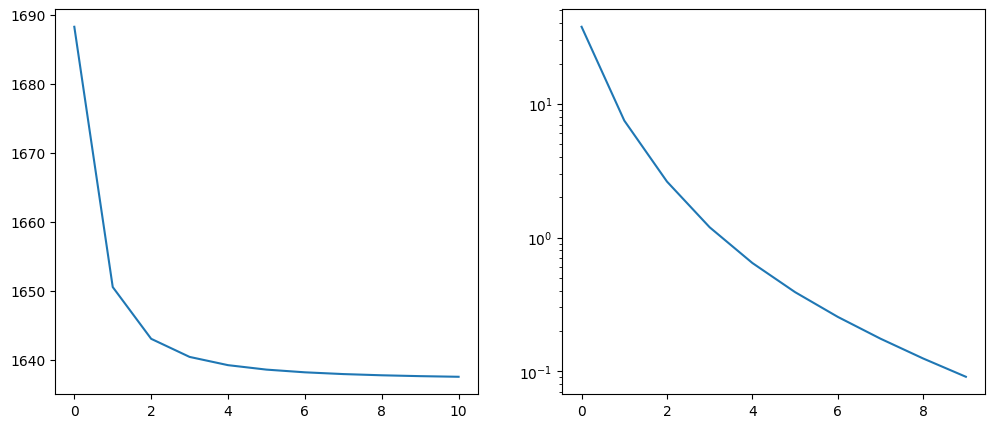

In [ ]:
rank = 30
U_als, VT_als, fs, deltas, dists = ALS(A_train, rank, 0.1, debug=True)

fig, axs = plt.subplots(figsize=(12, 5), ncols=2)

axs[0].plot(fs)
axs[1].plot(deltas)
axs[1].semilogy();

Расстояние между подпространствами на соседних итерациях:

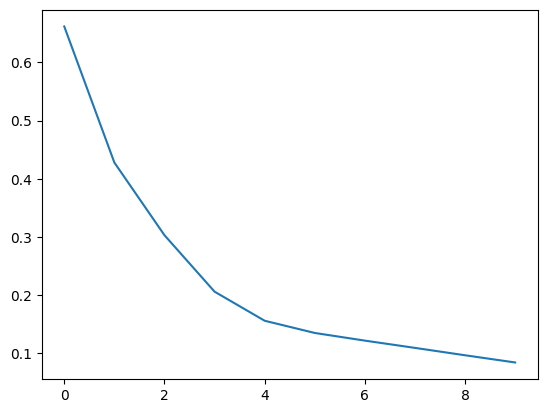

In [ ]:
plt.plot(dists)
plt.xlabel('Iteration')
plt.ylabel('Distance between subspaces')
plt.show()

## 4. Сравнение ALS, Randomized SVD и Sparse SVD

Сравним методы при одинаковом ранге факторизации `rank = 30` по ошибке малорангового приближения.

In [ ]:
from sklearn.utils.extmath import randomized_svd
from scipy.sparse.linalg import svds

A_norm = sparse_norm(A_train)

rank = 30
u, v, func_als, z, s = ALS(A_train, rank=rank)
als_res = func_als[-1]
U_rand, S_rand, VT_rand = randomized_svd(A_train, n_components=rank, random_state=30)
VT_rand = np.diag(S_rand) @ VT_rand
rand_res = als_functional(A_train, A_norm, U_rand, VT_rand)
U_sp, S_sp, VT_sp = svds(A_train, k=rank)
backward = np.flip(np.argsort(S_sp))
S_sp = S_sp[backward]
U_sp = U_sp[:, backward]
VT_sp = VT_sp[backward, :]
VT_sp = np.diag(S_sp) @ VT_sp
sp_res = als_functional(A_train, A_norm, U_sp, VT_sp)
print(f"ALS: {als_res:.4f}")
print(f"randomized svd: {rand_res:.4f}")
print(f"Sparse SVD: {sp_res:.4f}")

ALS: 1636.9117
randomized svd: 1636.9957
scipyvsvd: 1636.8722


В сохранённом запуске ошибки оказались очень близкими:

- ALS: около `1636.91`;
- Randomized SVD: около `1637.00`;
- Sparse SVD: около `1636.87`.

Sparse SVD дал минимальную ошибку, но различия между методами небольшие.

## 5. Генерация Top-N рекомендаций

Для пользователя вычисляются оценки фильмов в латентном пространстве, после чего выбираются фильмы с наибольшими предсказанными значениями.

In [ ]:
def recommend(VT, known_ratings, n_recs):
    """
        Input
            VT: 2D numpy array
            known_rating: sparse batch_size x n_movies array
            n_recs: requested number of recommendations

        Output
            recs: batch_size x n_recs array of movies to recommend, with descending predicted rating
    """
    X = known_ratings.toarray()
    res = X @ VT.T @ VT
    return np.argsort(-res, axis=1)[:, :n_recs]

## 6. Оценка качества рекомендаций

Для каждого тестового пользователя скрывается один фильм с положительной оценкой.  
После этого проверяется, попал ли скрытый фильм в Top-N рекомендаций.

In [ ]:
from scipy.sparse import find

def evaluate_model(VT, A_test, n_recs, batch_size=500):
    """
        Input
            VT: 2D numpy array representing the rating model
            A_test: sparse n_test x n_movies array corresponding to new users
            n_recs: requested number of recommendations
            batch_size: number of users to build recommendations for in a single call to recommend

        Output
            hit_idx: list of n_test ints: place of secret movie 
                     in top-n_recs recommendations (or n_recs if it is missing)
    """
    secrets = []
    nonempty_users = []
    A_test = A_test.copy()
    for user in range(A_test.shape[0]):
        _, good, _ = find(A_test[user,:])
        if len(good) == 0:
            continue
        nonempty_users.append(user)
        secret = np.random.choice(good, 1)[0]
        A_test[user, secret] = 0
        secrets.append(secret)
    hit_idx = []
    for i in range(0, len(nonempty_users), batch_size):
        # Build recomendations for a batch.
        recommendations = recommend(VT, A_test[nonempty_users[i:i + batch_size], :], n_recs + 1)
        # Place secret in the last column so that the following .argmax finds it.
        recommendations[:,-1] = secrets[i: i + batch_size]
        # Find secret among the recommendations and place its index into batch_hit_idx.
        batch_hit_idx = (recommendations == np.array([secrets[i:i + batch_size]]).T).argmax(1)
        hit_idx += batch_hit_idx.tolist()
    return hit_idx

In [ ]:
def get_hit_rates(VT, A_test, n_recs):
    """
        Input
            VT: 2D numpy array representing the rating model
            A_test: sparse n_test x n_movies array corresponding to new users 
            n_recs: list of ints: number of top recomendations to evaluate hit rate for
        Output
            hit_rates: list of float: hit rate for each element of n_recs

    """
    hit_idx = np.array(evaluate_model(VT, A_test, max(n_recs)))
    hit_rates = []
    for i in n_recs:
        hit_rate = np.mean(hit_idx < i)
        hit_rates.append(hit_rate)
    return hit_rates

Проверим Hit Rate@10 для Sparse SVD ранга 30 на первых 1000 пользователях тестовой выборки.

In [ ]:
U, S, VT = svds(A_train, k=30)
order = np.argsort(S)[::-1]
VT = VT[order, :]
hit_rate = get_hit_rates(VT, A_test[:1000], [10])[0]
print(hit_rate * 100)

9.836065573770492


В сохранённом запуске **Hit Rate@10 ≈ 9.84%**.

## 7. Влияние ранга факторизации и размера выдачи

Сравним ALS, Sparse SVD и Randomized SVD при рангах 5, 25 и 50 и разных размерах Top-N.

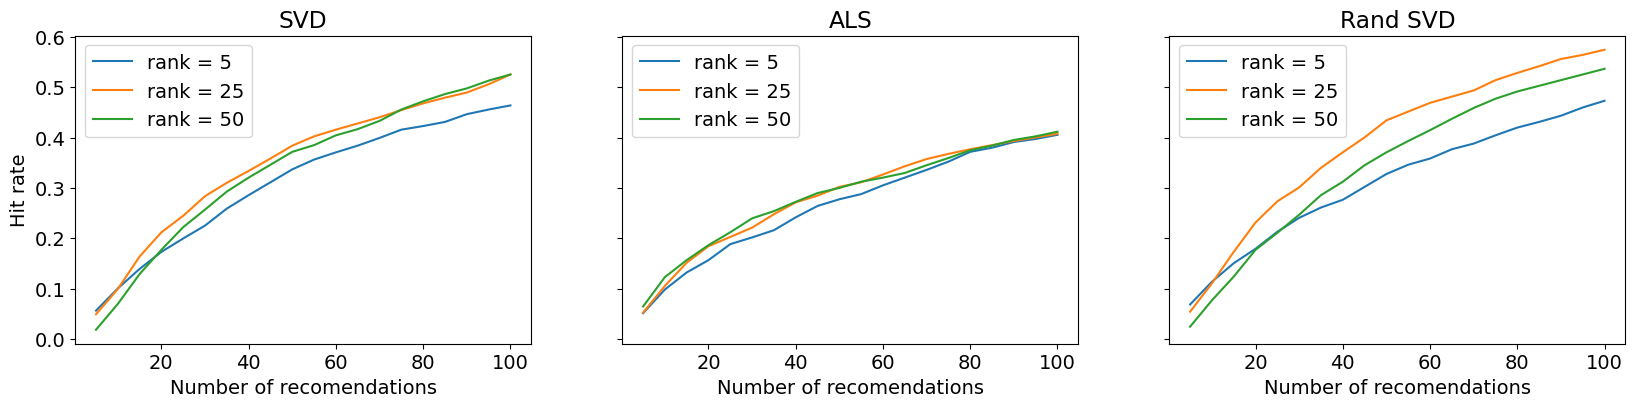

In [ ]:
from scipy.sparse.linalg import svds

n_recs = list(range(5, 101, 5))

plt.rcParams.update({'font.size': 14})
_, (ax_svd, ax_als, ax_rand) = plt.subplots(1,3,figsize=(20, 4),sharey=True)

ax_svd.set_title("SVD")
ax_svd.set_ylabel("Hit rate")
ax_als.set_title("ALS")
ax_rand.set_title("Rand SVD")
for rank in [5, 25, 50]:
    _, _, VT_svd = svds(A_train, k=rank)
    _, VT_als, _, _, _ = ALS(A_train, rank)
    _, _, VT_rand = randomized_svd(A_train, rank)
    for VT, ax in zip([VT_svd, VT_als, VT_rand], [ax_svd, ax_als, ax_rand]):
        ax.set_xlabel("Number of recomendations")
        hit_rates = get_hit_rates(VT, A_test[:1000,:], n_recs)
        line, = ax.plot(n_recs, hit_rates)
        line.set_label('rank = {}'.format(rank))
        ax.legend()

## 8. Выводы

По проведённому эксперименту:

- для Sparse SVD ранги 25 и 50 дают близкие результаты, поэтому ранг 25 выглядит разумным компромиссом между качеством и вычислительной стоимостью;
- для Randomized SVD аналогично наиболее удачным оказался ранг 25;
- для ALS результаты при разных рангах близки, при этом ранг 25 показал себя наиболее удачно.

Проект демонстрирует полный базовый pipeline рекомендательной системы: построение разреженной user-item матрицы, матричную факторизацию, генерацию Top-N рекомендаций и оценку результата по Hit Rate.